# Flipkart Product Catalog — Exploratory Data Analysis (EDA)

**What this project is about:**
This notebook studies product listings scraped from Flipkart (a major Indian
online marketplace) across **9 product categories**: baby products, books,
food, furniture, laptops, men's western wear, mobiles, women's footwear, and
women's western wear.

**What we do in this notebook, in plain terms:**
1. **Load** the raw data files (one file per category).
2. **Clean** the data — fix messy prices, missing values, and duplicate rows,
   so the numbers can actually be trusted.
3. **Explore** the cleaned data with tables and charts to answer simple
   business questions such as: *Which category is the most expensive?
   Which brands give the biggest discounts? Do higher prices lead to better
   ratings?*
4. **Summarize** what we found in a short list of plain-English insights at
   the end.

No prior data-science knowledge is required to follow along — every code
section below is preceded by a short note on *what it does and why*, and
every chart is followed by a short note on *how to read it*.

> **Tip for non-technical readers:** you can skip the grey code boxes
> entirely and just read the blue/white text and the charts — the notes
> tell you everything you need to know.

## Part 1 — Loading the Raw Data

In this part we simply find the data files on disk and read them into memory. No cleaning happens yet — we're just gathering the raw material.

### Step 1 — Import the Tools We Need

Before doing anything with data, we load a few standard Python libraries:

- **pandas** — the main tool for working with data tables (like Excel, but in code).
- **numpy** — helps with numbers and calculations.
- **matplotlib** and **seaborn** — used to draw charts and graphs.
- **pathlib** — helps us find files and folders on the computer.

This step doesn't produce any visible output — it just gets the toolkit ready.

In [1]:
# import os
# import glob
# import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

### Step 2 — Locate the Dataset Folder

Here we look for a folder called `flipkart_data`, which contains all the raw
CSV (spreadsheet-style) files exported from Flipkart. If the folder isn't in
the current location, the code automatically searches nearby folders for it,
so the notebook still works even if it's moved around.

In [2]:
DATA_DIR = Path("flipkart_data")

# If the folder is not found in the current directory,
# search for it inside subfolders.
if not DATA_DIR.exists():
    candidates = list(Path(".").glob("**/flipkart_data"))

    if candidates:
        DATA_DIR = candidates[0]

# Stop if the folder cannot be found.
if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Could not find 'flipkart_data' folder."
    )

print("Dataset folder:", DATA_DIR)


Dataset folder: flipkart_data


### Step 3 — List All the Data Files

Each CSV file represents **one product category**. The output below confirms
that all 9 expected category files were found before we try to load them.

In [3]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"\nFound {len(csv_files)} CSV files:")

for file in csv_files:
    print(" -", file.name)


Found 9 CSV files:
 - baby.csv
 - books.csv
 - food.csv
 - furn.csv
 - laptops.csv
 - mens_westernwear.csv
 - mobiles.csv
 - women_footwear.csv
 - women_westernwear.csv


### Step 4 — Load Every Category File

Now each CSV file is read into memory as a table. Two small housekeeping
tasks happen at the same time:

- The **Image URLS** column is removed (it's just a web link to a product
  photo and isn't useful for our analysis).
- A new **Category** column is added to every table, using the file name
  (e.g. `laptops.csv` → category `"laptops"`). This lets us tell the
  categories apart once everything is combined into one big table.

In [4]:
dfs = {}

for file in csv_files:

    # Read CSV
    df = pd.read_csv(file)

    # Remove Image URL column if it exists
    if "Image URLS" in df.columns:
        df = df.drop(columns=["Image URLS"])

    # Add category from filename
    df["Category"] = file.stem

    # Store dataframe
    dfs[file.stem] = df


print("\nAll datasets loaded successfully.")


All datasets loaded successfully.


### Step 5 — Quick Look at Each File

Before combining anything, it's good practice to check the basic shape of
each file: **how many products (rows)** it contains, **how many pieces of
information (columns)** are recorded, and **what those columns are called**.
This is a quick sanity check to catch obvious problems early.

In [5]:
dataset_summary = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Columns_List": ", ".join(
            df.columns.drop("Category")
        )
    }
    for name, df in dfs.items()
])

# Sort by number of rows
dataset_summary = dataset_summary.sort_values(
    "Rows",
    ascending=False
)

display(dataset_summary)

,Dataset,Rows,Columns,Columns_List
0,baby,800,5,"Product Name, Price, Original Prices, Discount..."
1,books,800,5,"Product Name, Price, Original Prices, Discount..."
2,food,800,5,"Product Name, Price, Original Prices, Discount..."
3,furn,800,5,"Product Name, Price, Original Prices, Discount..."
5,mens_westernwear,800,6,"Product Name, Price, Original Prices, Discount..."
8,women_westernwear,800,6,"Product Name, Price, Original Prices, Discount..."
7,women_footwear,800,6,"Product Name, Price, Original Prices, Discount..."
6,mobiles,600,6,"Product Name, Price, Original Prices, Discount..."
4,laptops,384,6,"Product Name, Price, Original Prices, Discount..."


**How to read this table:** each row is one product-category file. `Rows`
tells you how many products are listed in that category, and `Columns_List`
shows what information Flipkart recorded for that category (price, brand,
rating, etc. — different categories don't always record the same fields).

### Step 6 — Merge Everything Into One Master Table

All 9 category tables are now stacked on top of one another into a single
big table called `raw`. Working with one combined table (instead of 9
separate ones) makes it much easier to compare categories side by side later
in this notebook.

In [6]:
raw = pd.concat(
    dfs.values(),
    ignore_index=True
)

print("\nCombined dataset shape:", raw.shape)
print("Rows:", raw.shape[0])
print("Columns:", raw.shape[1])


Combined dataset shape: (6584, 7)
Rows: 6584
Columns: 7


**What this means:** the combined table now has one row per product,
across all categories, and the row/column counts above confirm the merge
worked as expected.

### Step 7 — Build a "Missing Data" Checker

Real-world data is rarely perfect — some fields are simply blank, some show
up as the text `"None"` or `"null"` instead of being truly empty, and pandas
represents blanks as a special value called `NaN`. This step defines a
reusable helper function that checks for **all three types** of missing data
in every column, so nothing slips through unnoticed.

In [7]:

def missing_value_report(df):
    """
    Check different types of missing values.
    """

    report = []

    for column in df.columns:

        # Real NaN / None
        real_nan = df[column].isna()

        # Convert values to string and remove spaces
        values = df[column].astype("string").str.strip()

        # Empty strings
        empty = values.eq("")

        # Text representations of missing values
        text_missing = values.isin([
            "nan",
            "NaN",
            "None",
            "none",
            "null",
            "NULL"
        ])

        # Total missing-like values
        total_missing = (
            real_nan |
            empty |
            text_missing
        )

        report.append({
            "Column": column,
            "Real_NaN": real_nan.sum(),
            "Empty": empty.sum(),
            "Text_NaN": text_missing.sum(),
            "Total_Missing": total_missing.sum(),
            "Missing_%": round(
                total_missing.mean() * 100,
                2
            )
        })

    return pd.DataFrame(report)

### Step 8 — See Which Columns Have Missing Data

Using the checker from Step 7, we now scan every category file and print
only the columns that actually contain missing values (columns with zero
missing values are hidden to keep the output easy to scan).

In [8]:

for name, df in dfs.items():

    print("\n" + "=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)

    report = missing_value_report(df)

    # Show only columns containing missing values
    report = report[
        report["Total_Missing"] > 0
    ]

    display(report)


DATASET: baby


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
2,Original Prices,118,0,0,118,14.75



DATASET: books


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
2,Original Prices,46,0,0,46,5.75



DATASET: food


...

,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
2,Original Prices,258,0,0,258,43.00
4,Ratings,13,0,0,13,2.17



DATASET: women_footwear


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
2,Original Prices,86,0,0,86,10.75
3,Discount rates,86,0,0,86,10.75



DATASET: women_westernwear


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
2,Original Prices,6,0,0,6,0.75
3,Discount rates,6,0,0,6,0.75
4,Brand,41,0,0,41,5.12


**Why this matters:** knowing exactly which columns have gaps — and how
many — tells us what needs to be fixed before we can trust any statistics
calculated from this data.

### Step 9 — Check for Duplicate Rows

Duplicate rows (the exact same product listed more than once) can distort
averages and counts, making a category look bigger or more popular than it
really is. Here we count how many duplicate rows exist in each category
file, and then in the combined table, before deciding what to do about
them.

In [9]:

duplicate_report = []

for name, df in dfs.items():

    duplicate_count = df.duplicated().sum()

    duplicate_report.append({
        "Dataset": name,
        "Total_Rows": len(df),
        "Duplicate_Rows": duplicate_count,
        "Duplicate_%": round(
            duplicate_count / len(df) * 100,
            2
        )
    })

duplicate_report = pd.DataFrame(
    duplicate_report
)

duplicate_report = duplicate_report.sort_values(
    "Duplicate_Rows",
    ascending=False
)

display(duplicate_report)

,Dataset,Total_Rows,Duplicate_Rows,Duplicate_%
7,women_footwear,800,261,32.62
5,mens_westernwear,800,216,27.00
3,furn,800,214,26.75
8,women_westernwear,800,209,26.12
2,food,800,181,22.62
0,baby,800,169,21.12
1,books,800,164,20.50
6,mobiles,600,79,13.17
4,laptops,384,70,18.23


In [10]:
raw.duplicated().groupby(raw["Category"]).sum()

Category
baby                 169
books                164
food                 181
furn                 214
laptops               70
mens_westernwear     216
mobiles               79
women_footwear       261
women_westernwear    209
dtype: int64

**What this shows:** the table above ranks categories by how many
duplicate rows they contain, and the line below it breaks the same count
down by category once all files are combined. We'll remove these duplicates
properly a bit further down, once the prices are cleaned up too.

## Part 2 — Cleaning the Data

Raw data exported from a website is almost never analysis-ready. Prices come in as text like `"₹1,299"`, discounts show up as `"20% off"`, and some fields are simply missing. This part turns messy text into clean numbers we can calculate with.

### Step 10 — Build a Price-Cleaning Tool

Flipkart prices are stored as **text**, not numbers — for example `"₹1,299"`
instead of `1299`. This step creates a small reusable function that:

1. Strips out currency symbols, commas, and any other non-numeric characters.
2. Converts the leftover text into a proper number that Python can do
   maths with.

This function will be applied to every price-related column in the next
step.

In [11]:

def clean_money(series):

    return (
        series
        .astype("string")
        .str.replace(
            r"[^0-9.\-]",
            "",
            regex=True
        )
        .replace({
            "": np.nan,
            "nan": np.nan,
            "NaN": np.nan
        })
        .astype(float)
    )

### Step 11 — Clean the Price Columns

The price-cleaning tool from Step 10 is now applied to both the **Price**
(what the customer actually pays) and **Original Prices** (the price before
any discount) columns, in every category. If a product has no listed
"original price," we assume it was never discounted and simply reuse its
selling price instead — this avoids losing that product from later
calculations.

In [12]:

for name, df in dfs.items():

    print(f"\nProcessing: {name}")

    # Clean selling price
    if "Price" in df.columns:
        df["Price"] = clean_money(
            df["Price"]
        )

    # Clean original price
    if "Original Prices" in df.columns:
        df["Original Prices"] = clean_money(
            df["Original Prices"]
        )

    # If Original Price is missing,
    # use Selling Price instead.
    if (
        "Original Prices" in df.columns
        and "Price" in df.columns
    ):

        df["Original Prices"] = (
            df["Original Prices"]
            .fillna(df["Price"])
        )

    print("Price columns cleaned.")


Processing: baby
Price columns cleaned.

Processing: books
Price columns cleaned.

Processing: food
Price columns cleaned.

Processing: furn
Price columns cleaned.

Processing: laptops
Price columns cleaned.

Processing: mens_westernwear
Price columns cleaned.

Processing: mobiles
Price columns cleaned.

Processing: women_footwear
Price columns cleaned.

Processing: women_westernwear
Price columns cleaned.


### Step 12 — Clean the Discount Percentages

Discount values arrive as text like `"20% off"`. This step removes the
`"% off"` wording, converts what's left into a plain number (e.g. `20`), and
treats any product with no discount information as having a **0% discount**
(rather than leaving it blank).

In [13]:

for name, df in dfs.items():

    if "Discount rates" not in df.columns:
        continue

    # Remove "% off"
    df["Discount rates"] = (
        df["Discount rates"]
        .astype("string")
        .str.replace(
            "% off",
            "",
            case=False,
            regex=False
        )
        .str.strip()
    )

    # Convert missing/text values to NaN
    df["Discount rates"] = (
        df["Discount rates"]
        .replace([
            "",
            "nan",
            "NaN",
            "None",
            "none"
        ], np.nan)
    )

    # Convert to numeric
    df["Discount rates"] = pd.to_numeric(
        df["Discount rates"],
        errors="coerce"
    )

    # Replace missing discount with 0
    df["Discount rates"] = (
        df["Discount rates"]
        .fillna(0)
    )

print("Discount rates cleaned.")

Discount rates cleaned.


### Step 13 — Re-combine the Cleaned Data

Now that prices and discounts have been cleaned inside each category table,
we merge all 9 tables back into a single combined table again, this time
using the cleaned values.

In [14]:

raw = pd.concat(
    dfs.values(),
    ignore_index=True
)

print("Cleaned combined dataset shape:")
print(raw.shape)

Cleaned combined dataset shape:
(6584, 7)


### Step 14 — Re-check Missing Values After Cleaning

Using the same checker function from Step 7, we look again for missing
values — this time *after* cleaning — to confirm the cleaning steps actually
reduced the number of problem cells rather than introducing new ones.

In [15]:

for name, df in dfs.items():

    print("\n" + "=" * 60)
    print(f"AFTER CLEANING: {name}")
    print("=" * 60)

    report = missing_value_report(df)

    report = report[
        report["Total_Missing"] > 0
    ]

    display(report)


AFTER CLEANING: baby


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%



AFTER CLEANING: books


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%



AFTER CLEANING: food


...

,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
4,Ratings,13,0,0,13,2.17



AFTER CLEANING: women_footwear


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%



AFTER CLEANING: women_westernwear


,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
4,Brand,41,0,0,41,5.12


### Step 15 — Final Look at the Combined Dataset

Here we take a full snapshot of the cleaned, combined dataset:

- **Shape** — total number of products and columns.
- **Data types** — confirms prices and discounts are now stored as numbers,
  not text.
- **First 5 rows** — a quick visual spot-check of what the data actually
  looks like.
- **Statistical summary** — a birds-eye view (count, average, minimum,
  maximum, etc.) of every column at once.

In [16]:

print("Final dataset shape:", raw.shape)

print("\nData types:")
display(raw.dtypes.to_frame("Data_Type"))

print("\nFirst 5 rows:")
display(raw.head())

print("\nStatistical summary:")
display(raw.describe(include="all").T)

Final dataset shape: (6584, 7)

Data types:


,Data_Type
Product Name,str
Price,float64
Original Prices,float64
Discount rates,Int64
Category,str
Ratings,float64
Brand,str



First 5 rows:


,Product Name,Price,Original Prices,Discount rates,Category,Ratings,Brand
0,Pampers Baby-Dry Pants Diaper - New Born,891.0,1049.0,15,baby,NaN,NaN
1,Mamaearth Complete Baby Care Kit with Baby Lot...,979.0,1195.0,18,baby,NaN,NaN
2,Billion Extra Absorb Diaper Pants - M,649.0,975.0,33,baby,NaN,NaN
3,Himalaya Total Care Baby Pants - XL,637.0,850.0,25,baby,NaN,NaN
4,MamyPoko Pants Extra Absorb Diapers - L,1154.0,1499.0,23,baby,NaN,NaN



Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product Name,6584,4054,Walking Shoes For Women,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,6583.0,NaN,NaN,NaN,5538.975543,18423.797798,10.0,299.0,511.0,1156.5,348990.0
Original Prices,6583.0,NaN,NaN,NaN,6849.609145,20738.307133,10.0,499.0,999.0,1999.0,349817.0
Discount rates,6584.0,<NA>,<NA>,<NA>,31.470231,24.401006,0.0,10.0,27.0,52.0,88.0
Category,6584,9,baby,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ratings,876.0,NaN,NaN,NaN,4.154566,0.373633,1.6,3.9,4.2,4.5,5.0
Brand,2326,534,Action,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 16 — Re-check Duplicates After Cleaning

Duplicates are counted again after cleaning, per category, to make sure the
picture hasn't changed unexpectedly during the cleaning process.

In [17]:

duplicates_after = []

for name, df in dfs.items():

    duplicate_count = df.duplicated().sum()

    duplicates_after.append({
        "Dataset": name,
        "Rows": len(df),
        "Duplicate_Rows": duplicate_count,
        "Duplicate_%": round(
            duplicate_count / len(df) * 100,
            2
        )
    })

duplicates_after = pd.DataFrame(
    duplicates_after
)

display(
    duplicates_after.sort_values(
        "Duplicate_Rows",
        ascending=False
    )
)

,Dataset,Rows,Duplicate_Rows,Duplicate_%
7,women_footwear,800,261,32.62
5,mens_westernwear,800,216,27.00
3,furn,800,214,26.75
8,women_westernwear,800,209,26.12
2,food,800,181,22.62
0,baby,800,169,21.12
1,books,800,164,20.50
6,mobiles,600,79,13.17
4,laptops,384,70,18.23


Below is a quick manual spot-check of one category (**food**) — looking
directly at 50 sample rows is a simple way to visually confirm the cleaning
worked correctly before trusting it for the rest of the categories.

In [18]:
for name, df in dfs.items():
    if name == "food":
        # print(df['Original Prices'].isnull().sum())
        display(df.head(50))

,Product Name,Price,Original Prices,Discount rates,Category
0,Madhur Sugar,48.0,55.0,12,food
1,Rajdhani Rajma Chithra (Whole),179.0,180.0,0,food
2,Tata Iodized Salt,20.0,20.0,0,food
3,Emami Healthy & Tasty Kachchi Ghani Mustard Oi...,133.0,155.0,14,food
4,Roxy Gold Maida,53.0,55.0,3,food
5,Parry's White Label Sugar,59.0,60.0,1,food
6,Maggi Masala Instant Noodles Vegetarian,46.0,46.0,0,food
7,Flipkart Supermart Select Cumin Seeds (Jeera),69.0,128.0,46,food
8,Fortune Sunlite Refined Sunflower Oil Pouch,114.0,130.0,12,food
9,Freedom Refined Sunflower Oil Pouch,111.0,114.0,2,food


### Step 17 — Combine All Cleaned Category Tables Again

The category tables are merged one more time into the final combined
table, `raw`, which will be used for every analysis step from here onward.

In [19]:

raw = pd.concat(
    dfs.values(),
    ignore_index=True
)

print("Combined dataset shape:", raw.shape)
display(raw.head(5000))

Combined dataset shape: (6584, 7)


,Product Name,Price,Original Prices,Discount rates,Category,Ratings,Brand
0,Pampers Baby-Dry Pants Diaper - New Born,891.0,1049.0,15,baby,NaN,NaN
1,Mamaearth Complete Baby Care Kit with Baby Lot...,979.0,1195.0,18,baby,NaN,NaN
2,Billion Extra Absorb Diaper Pants - M,649.0,975.0,33,baby,NaN,NaN
3,Himalaya Total Care Baby Pants - XL,637.0,850.0,25,baby,NaN,NaN
4,MamyPoko Pants Extra Absorb Diapers - L,1154.0,1499.0,23,baby,NaN,NaN
...,...,...,...,...,...,...,...
4995,Combo Pack Of 2 Pairs Of Women Slides Flip Flo...,329.0,999.0,67,women_footwear,NaN,Beonza
4996,Slides,299.0,499.0,40,women_footwear,NaN,Brauch
4997,NRGY Neko Wn s Running Shoes For Women,2699.0,5999.0,55,women_footwear,NaN,Puma
4998,Angel-04 Casual sneakers for ladies | sports s...,584.0,999.0,41,women_footwear,NaN,Asian


### Step 18 — Final Missing-Value Check

One last check confirms whether any missing values remain anywhere in the
fully combined, cleaned dataset.

In [20]:

final_missing = missing_value_report(raw)

if final_missing.empty:
    print("No missing values found.")
else:
    display(final_missing)

,Column,Real_NaN,Empty,Text_NaN,Total_Missing,Missing_%
0,Product Name,0,0,0,0,0.00
1,Price,1,0,0,1,0.02
2,Original Prices,1,0,0,1,0.02
3,Discount rates,0,0,0,0,0.00
4,Category,0,0,0,0,0.00
5,Ratings,5708,0,0,5708,86.70
6,Brand,4258,0,0,4258,64.67


### Step 19 — Final Duplicate Check

A final duplicate count on the fully combined table, right before we
actually remove them in the next step.

In [21]:

print("Total duplicate rows:", raw.duplicated().sum())

Total duplicate rows: 1563


### Step 20 — Remove Duplicate Rows

Now that we've confirmed how many duplicate rows exist, we remove them for
good. The output shows the row count **before** and **after**, so it's clear
exactly how much data was affected by this step.

In [22]:

before = len(raw)

raw = raw.drop_duplicates().reset_index(drop=True)

after = len(raw)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates :", after)
print("Duplicates removed             :", before - after)

Rows before removing duplicates: 6584
Rows after removing duplicates : 5021
Duplicates removed             : 1563


**Why we do this:** a handful of duplicate rows for the *same exact*
listing don't add real information — they would only artificially inflate
counts and skew averages toward whichever product happened to be duplicated
in the original export.

## Part 3 — Exploring the Data

With clean data in hand, we can now start answering real business questions using summary tables and charts.

### Step 21 — Summary Statistics per Category

This table calculates, for every category, the number of products along
with average / median / minimum / maximum values for both selling price and
original price, plus average / median / maximum discount. It's essentially
a one-table overview of the entire dataset.

In [23]:

category_summary = (
    raw.groupby("Category")
    .agg(
        Products=("Product Name", "count"),
        
        Avg_Price=("Price", "mean"),
        Median_Price=("Price", "median"),
        Min_Price=("Price", "min"),
        Max_Price=("Price", "max"),

        Avg_Original_Price=("Original Prices", "mean"),
        Median_Original_Price=("Original Prices", "median"),
        Min_Original_Price=("Original Prices", "min"),
        Max_Original_Price=("Original Prices", "max"),

        Avg_Discount=("Discount rates", "mean"),
        Median_Discount=("Discount rates", "median"),
        # Min_Discount=("Discount rates", "min"),   # zero 
        Max_Discount=("Discount rates", "max"),
    )
    .round(2)
    .sort_values("Avg_Price", ascending=False)
)

# display(category_summary)
display(category_summary.round(2))

,Products,Avg_Price,Median_Price,Min_Price,Max_Price,Avg_Original_Price,Median_Original_Price,Min_Original_Price,Max_Original_Price,Avg_Discount,Median_Discount,Max_Discount
Category,,,,,,,,,,,,
laptops,314,68655.69,58744.5,13990.0,348990.0,79097.18,70533.0,19999.0,349817.0,13.21,10.0,47
mobiles,521,10979.52,7499.0,499.0,73600.0,12699.99,9999.0,499.0,89900.0,12.24,5.0,75
furn,586,3969.01,1488.5,127.0,39290.0,6428.87,2757.0,199.0,70000.0,40.69,40.0,88
women_footwear,539,633.74,418.0,121.0,7496.0,1069.53,799.0,139.0,9995.0,36.66,40.0,81
baby,631,541.74,357.0,30.0,3499.0,738.02,499.0,30.0,5999.0,19.73,12.0,82
women_westernwear,591,465.48,404.0,189.0,2716.0,1300.95,1199.0,204.0,4199.0,62.05,64.0,85
mens_westernwear,584,436.31,390.0,97.0,1686.0,1137.22,999.0,169.0,3199.0,56.01,61.0,88
food,619,423.43,335.0,10.0,5025.0,545.01,400.0,10.0,5990.0,16.63,11.0,77
books,636,371.63,274.0,19.0,3619.0,492.66,390.0,30.0,4900.0,23.06,22.0,69


**How to read this table:** each row is a category, sorted from the
**most expensive on average (top)** to the **least expensive on average
(bottom)**. Comparing `Avg_Price` to `Median_Price` is useful too — if they
are very different, it usually means a few very expensive products are
pulling the average up (median is less affected by such extreme values).

### Step 22 — Overall Price Statistics

Beyond the per-category view, this looks at selling price and original
price **across the entire dataset** (all categories combined) using
pandas' built-in `.describe()` summary: count, average, spread, and the
minimum/maximum/quartile values.

In [24]:

price_summary = raw["Price"].describe()

display(price_summary)

count      5020.000000
mean       6238.132072
std       20611.285094
min          10.000000
25%         299.000000
50%         498.000000
75%        1099.000000
max      348990.000000
Name: Price, dtype: float64

In [25]:
original_price = raw["Original Prices"].describe()
display(original_price)

count      5020.000000
mean       7638.612948
std       23179.060645
min          10.000000
25%         496.750000
50%         999.000000
75%        1999.000000
max      349817.000000
Name: Original Prices, dtype: float64

**What these numbers mean:** `mean` is the average price, `std`
(standard deviation) shows how spread out the prices are, and `25%` / `50%`
/ `75%` are the price points below which that percentage of products fall
(the `50%` value is the median).

### Step 23 — Discount and Rating Statistics

The same kind of summary is now produced for **discount percentages** and
**customer ratings** across the whole dataset.

In [26]:

discount_summary = raw["Discount rates"].describe()

display(discount_summary)

count       5021.0
mean     32.047401
std      24.980258
min            0.0
25%           10.0
50%           29.0
75%           54.0
max           88.0
Name: Discount rates, dtype: Float64

In [27]:
rating_summary = raw["Ratings"].describe()
display(rating_summary)

count    728.000000
mean       4.174176
std        0.376136
min        1.600000
25%        3.900000
50%        4.300000
75%        4.500000
max        5.000000
Name: Ratings, dtype: float64

**What to look for:** a high average discount combined with a wide
spread (large `std`) suggests some categories or products are discounted
far more aggressively than others. For ratings, most e-commerce platforms
see values cluster between 3 and 4.5 out of 5.

### Step 24 — Chart: How Many Products Are in Each Category?

Our first chart. This horizontal bar chart simply counts how many products
are listed under each category.

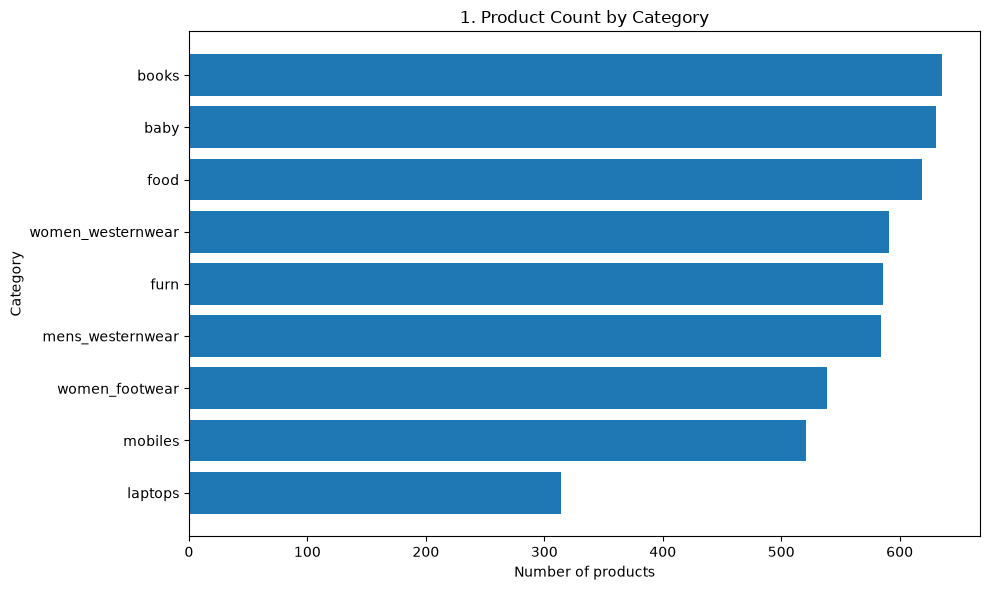

In [28]:

counts = raw["Category"].value_counts().sort_values()
plt.figure(figsize=(10,6))
plt.barh(counts.index, counts.values.tolist())
plt.title("1. Product Count by Category")
plt.xlabel("Number of products")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**How to read this chart:** each bar represents one category — the
longer the bar, the more products Flipkart lists in that category. This
reflects **catalog size**, not necessarily sales volume or popularity.

### Step 25 — Chart: Average Price by Category

This bar chart compares the **average selling price** across categories,
ordered from the most expensive category to the least expensive.

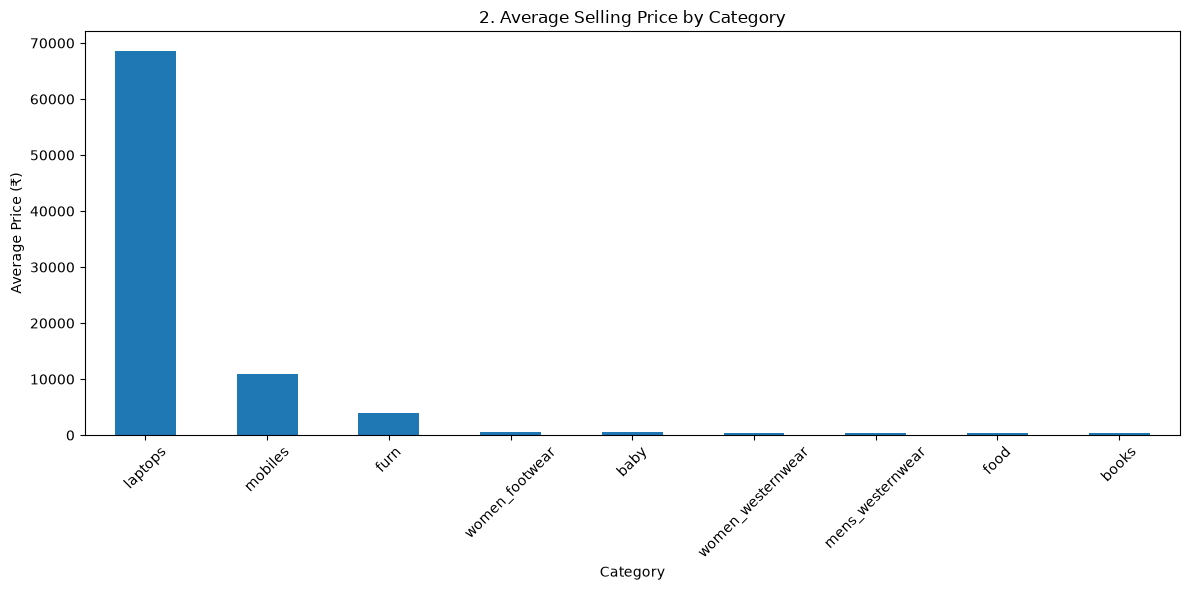

In [29]:

avg_price = (
    raw.groupby("Category")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

avg_price.plot(kind="bar")

plt.title("2. Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**How to read this chart:** taller bars mean a higher average price for
that category. Categories like laptops or mobiles are typically far more
expensive on average than everyday items like books or food, so expect a
large gap between the tallest and shortest bars.

### Step 26 — Chart: Median Price by Category

This chart shows the **median** price per category instead of the average.
The median is the "middle" price — half the products in that category cost
more, and half cost less.

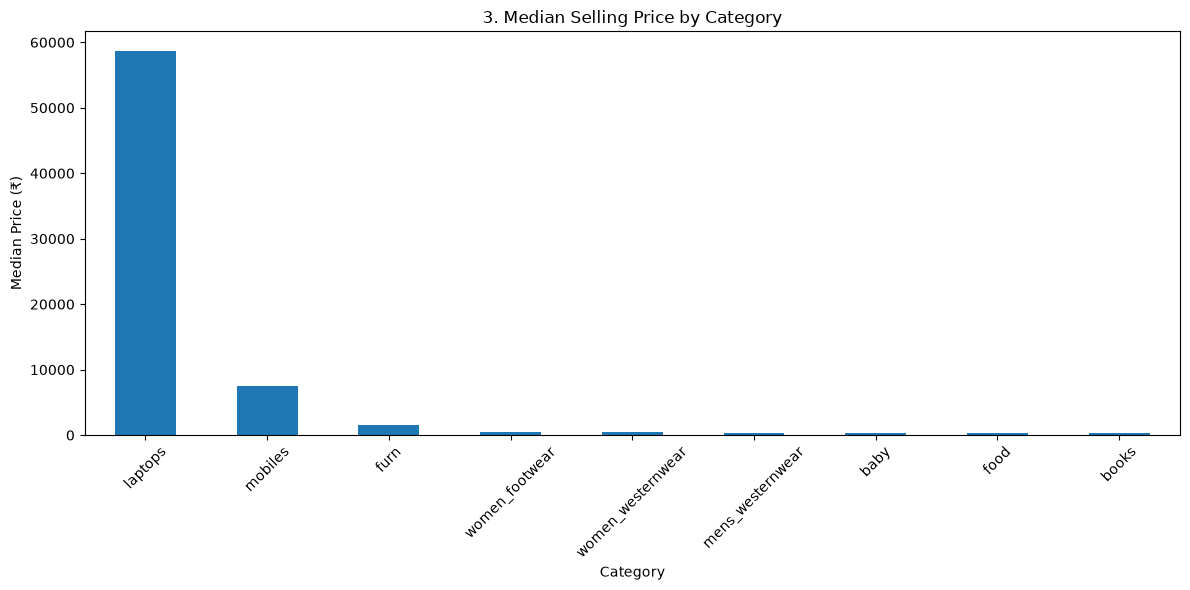

In [30]:

median_price = (
    raw.groupby("Category")["Price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

median_price.plot(kind="bar")

plt.title("3. Median Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Median Price (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Why look at median as well as average:** a small number of very
expensive products (e.g. premium laptops) can pull the *average* price
upward even if most products in that category are actually cheap. The
median is not affected by these extreme values, so comparing the two charts
tells us whether a category's pricing is skewed by a few outliers.

### Step 27 — Chart: Average Discount by Category

This bar chart shows which categories tend to carry the **biggest listed
discounts**, on average.

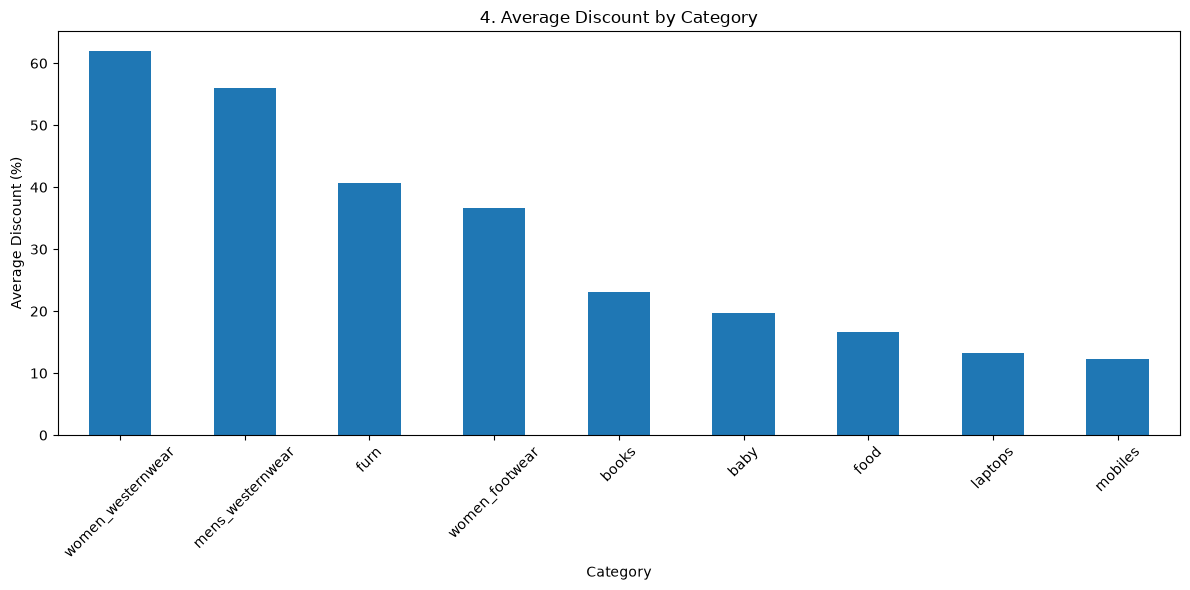

In [31]:

avg_discount = (
    raw.groupby("Category")["Discount rates"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

avg_discount.plot(kind="bar")

plt.title("4. Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**How to read this chart:** taller bars mean shoppers can typically find
bigger percentage discounts in that category. This doesn't necessarily mean
those products end up cheaper overall — just that the gap between the
original price and the selling price tends to be larger.

### Step 28 — Chart: Overall Price Distribution

This histogram shows how selling prices are spread out across **every**
product in the dataset, regardless of category. The x-axis uses a
logarithmic scale, which is a standard way to display prices when they
range from a few rupees to hundreds of thousands — without it, the cheap
majority of products would be squashed into an unreadable sliver on the
left.

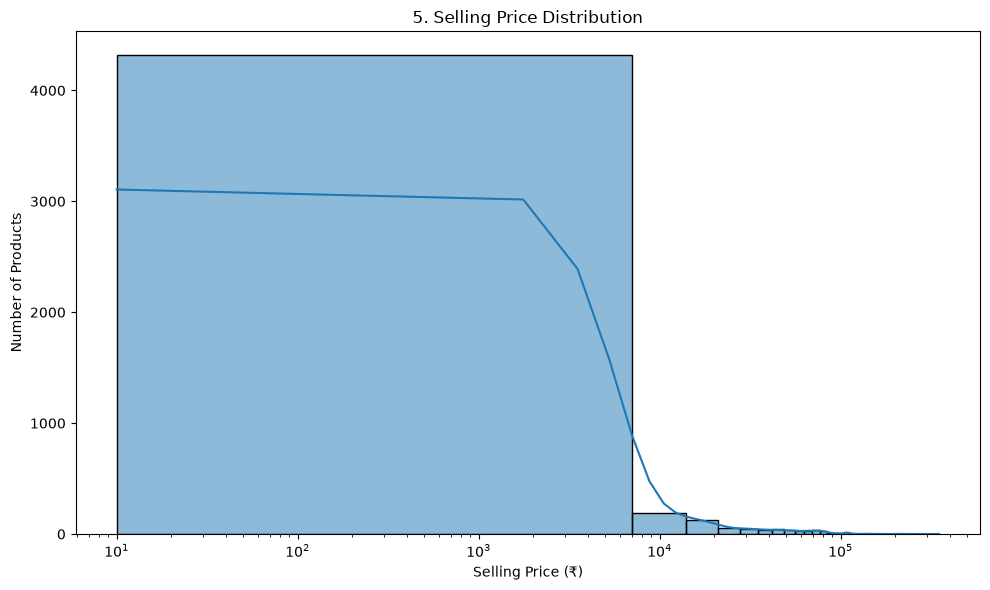

In [32]:

plt.figure(figsize=(10, 6))

sns.histplot(
    raw["Price"].dropna(),
    bins=50,
    kde=True
)
plt.xscale("log")
plt.title("5. Selling Price Distribution")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

**How to read this chart:** each bar's height shows how many products
fall into that price range. The smooth curve overlaid on top (called a KDE
curve) is just a smoothed version of the same information, making the
overall shape easier to see. A tall peak means many products share a
similar price.

### Step 29 — Chart: Discount Distribution

Similarly, this histogram shows how discount percentages are distributed
across all products.

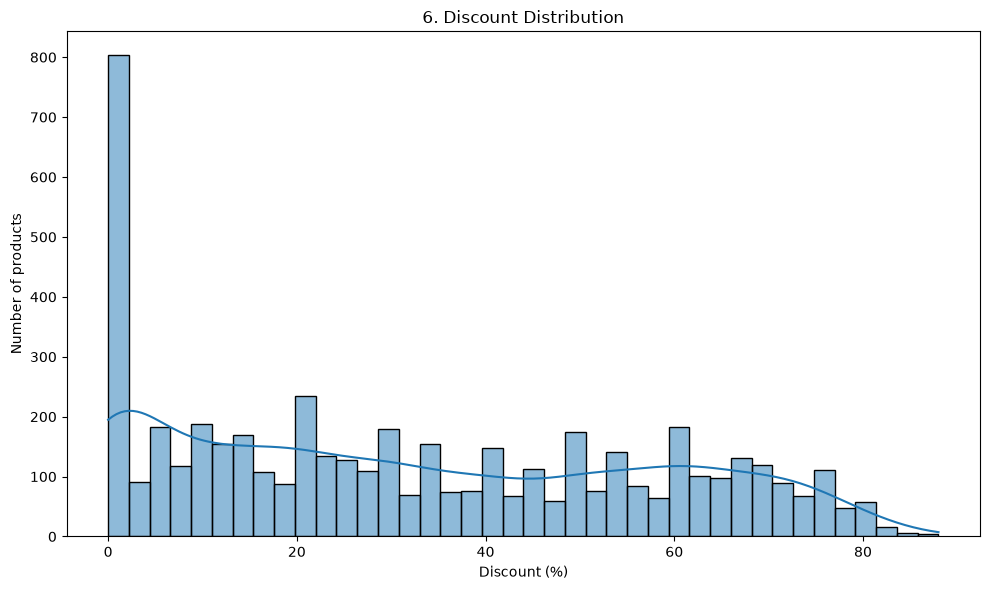

In [33]:

plt.figure(figsize=(10,6))
sns.histplot(x=raw["Discount rates"].dropna(), bins=40, kde=True)
plt.title("6. Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()

**How to read this chart:** the x-axis is the discount percentage, and
the height of each bar shows how many products received that level of
discount. A peak around a particular percentage (e.g. 30–50%) tells you
that's the "typical" discount shoppers see across the catalog.

### Step 30 — Chart: Price Distribution by Category (Box Plot)

This box plot compares the **full price range** for every category side by
side, again using a logarithmic scale for readability.

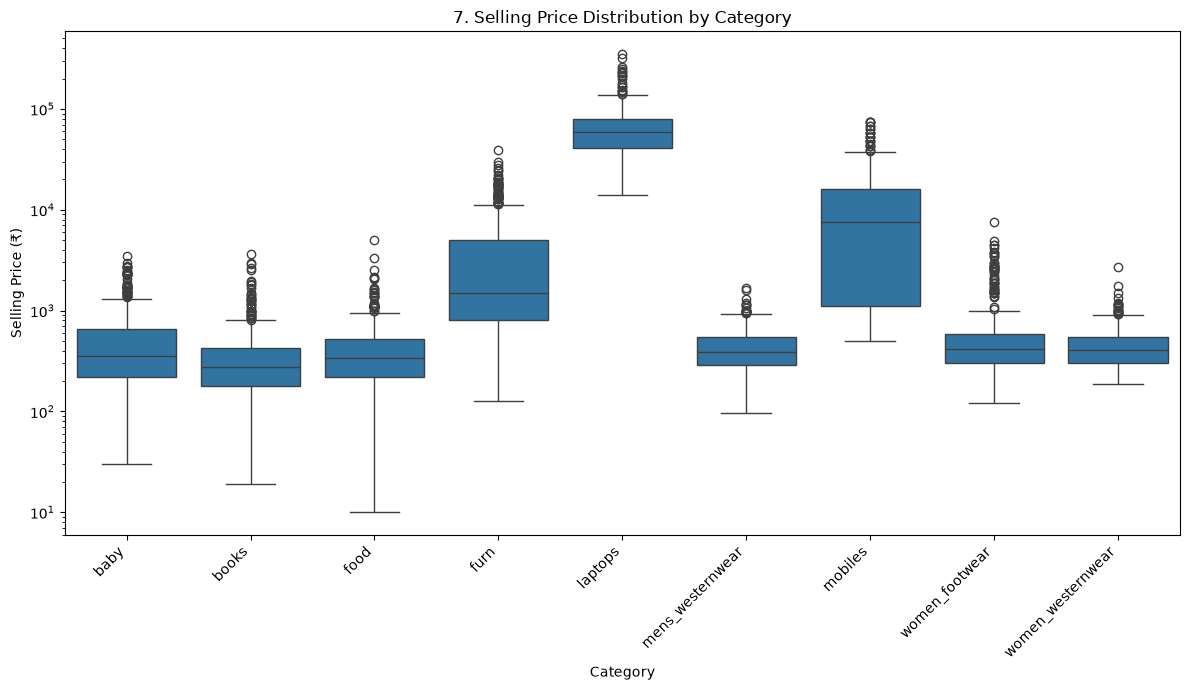

In [34]:

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=raw,
    x="Category",
    y="Price"
)
plt.yscale("log")
plt.title("7. Selling Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Selling Price (₹)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**How to read a box plot:**
- The **box** covers the middle 50% of prices in that category.
- The **line inside the box** is the median price.
- The **whiskers** (thin lines extending from the box) show the typical
  range of prices outside the middle 50%.
- Individual **dots** above or below the whiskers are outliers — unusually
  cheap or expensive products compared to the rest of that category.

### Step 31 — Chart: Discount Distribution by Category (Box Plot)

The same box-plot approach, applied to discount percentages instead of
price, letting us compare how aggressively each category is discounted.

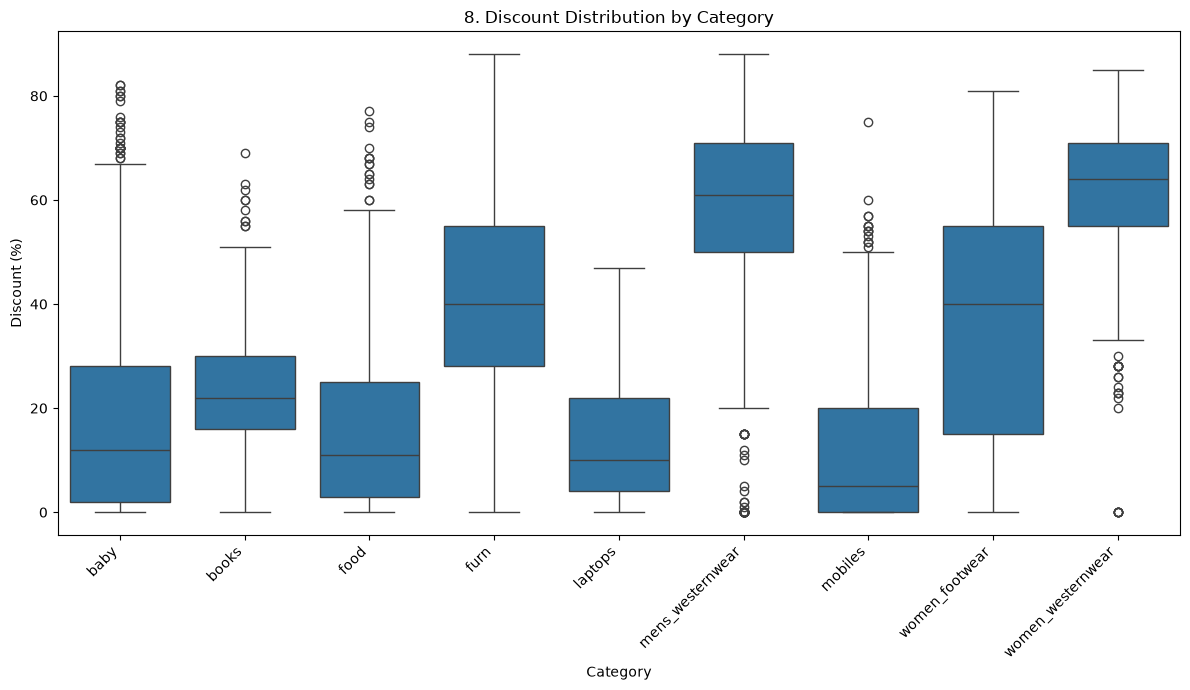

In [35]:

plt.figure(figsize=(12,7))
sns.boxplot(data=raw, x="Category", y="Discount rates") 
plt.xticks(rotation=45, ha="right")
plt.title("8. Discount Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Discount (%)")
plt.tight_layout()
plt.show()

**What to look for:** categories with a tall box (wide spread) offer
very inconsistent discounts — some products barely discounted, others
heavily discounted. Categories with a short, high box consistently offer
large discounts across most of their products.

### Step 32 — Chart: Original Price vs. Selling Price

This scatter plot places every product on a grid, comparing its **original
price** (x-axis) against its **actual selling price** (y-axis). Both axes
use a logarithmic scale because prices span such a wide range.

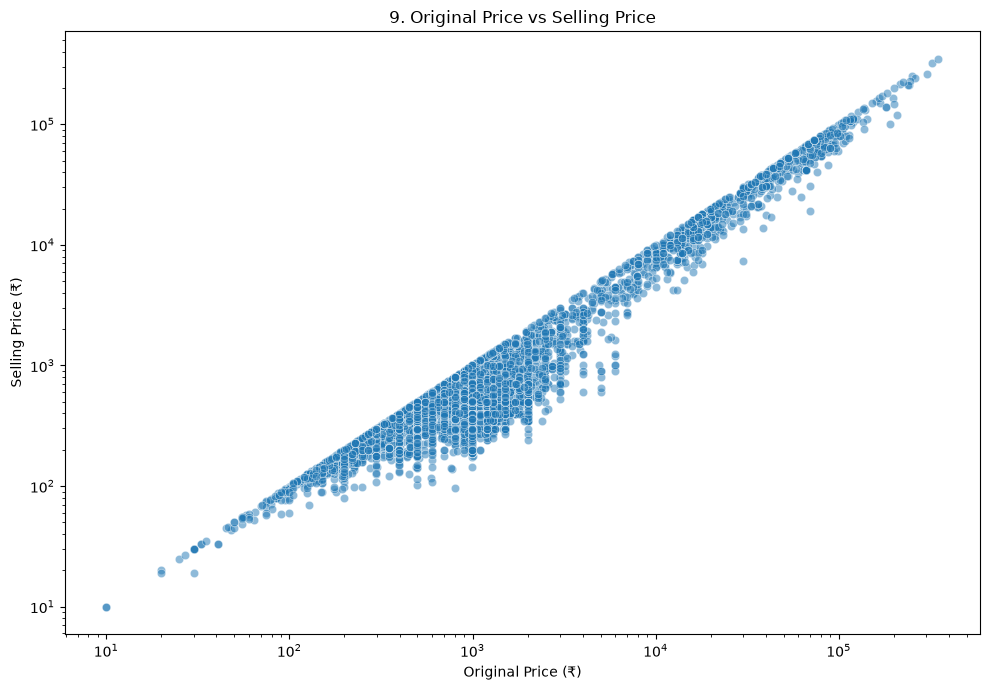

In [36]:

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=raw,
    x="Original Prices",
    y="Price",
    alpha=0.5
)
plt.xscale("log"); plt.yscale("log")
plt.title("9. Original Price vs Selling Price")
plt.xlabel("Original Price (₹)")
plt.ylabel("Selling Price (₹)")

plt.tight_layout()
plt.show()

**How to read this chart:** each dot is one product. If a product had no
discount at all, its dot would sit exactly on a diagonal line running from
bottom-left to top-right (original price = selling price). Dots that fall
**below** that imaginary diagonal represent products sold at a discount —
the further below the line, the bigger the discount.

### Step 33 — Table: The 20 Most Expensive Products

A simple ranked table listing the top 20 highest-priced products across the
entire dataset, along with their category, brand, original price, discount,
and rating.

In [37]:
top_expensive = (
    raw.dropna(subset=["Price"])
    .sort_values("Price", ascending=False)
    [["Category","Product Name","Price","Original Prices","Discount rates", "Ratings", "Brand"]]
    .head(20)
)
display(top_expensive)

,Category,Product Name,Price,Original Prices,Discount rates,Ratings,Brand
2653,laptops,Alienware 17 Core i9 8th Gen - (32 GB/1 TB HDD...,348990.0,349817.0,0,NaN,NaN
2622,laptops,Alienware 15 Core i9 8th Gen - (32 GB/1 TB HDD...,320990.0,321609.0,0,NaN,NaN
2521,laptops,Asus ZenBook Pro Duo Core i9 9th Gen - (32 GB/...,259990.0,302990.0,14,NaN,NaN
2574,laptops,Dell XPS 15 Core i9 9th Gen - (32 GB/1 TB SSD/...,249990.0,250222.0,0,NaN,NaN
2626,laptops,Apple Macbook Pro Core i7 8th Gen - (16 GB/512...,239990.0,259990.0,7,4.0,NaN
2627,laptops,Apple MacBook Pro Core i7 7th Gen - (16 GB/512...,229990.0,244990.0,6,NaN,NaN
2763,laptops,Lenovo Core i7-8550U Core i7 7th Gen - (16 GB/...,225000.0,225000.0,0,NaN,NaN
2611,laptops,HP Spectre Folio x360 Core i7 8th Gen - (16 GB...,215000.0,215909.0,0,NaN,NaN
2668,laptops,Apple MacBook Pro Core i9 8th Gen - (16 GB/512...,209990.0,239900.0,12,4.7,NaN
2531,laptops,Asus ZenBook Pro Duo Core i7 9th Gen - (32 GB/...,209990.0,242990.0,13,NaN,NaN


**Why this is useful:** looking at real, named examples of the priciest
products grounds the abstract charts above in concrete, relatable
detail — useful for a report or presentation.

### Step 34 — Rating Summary by Category

For every category that has customer ratings recorded, this table shows how
many rated products exist, plus the average, median, minimum, and maximum
rating.

In [38]:

rating_summary = (
    raw[raw["Ratings"].notna()]
    .groupby("Category")["Ratings"]
    .agg(["count","mean","median","min","max"])
    .round(2)
)
display(rating_summary)

,count,mean,median,min,max
Category,,,,,
laptops,219,4.18,4.2,1.6,5.0
mobiles,509,4.17,4.3,2.7,4.7


**Note:** not every category has ratings recorded for every product —
some categories may have far fewer rated items than others, which is worth
keeping in mind when comparing average ratings between categories.

### Step 35 — Chart: Rating Distribution by Category (Box Plot)

A box plot comparing the spread of customer ratings across categories that
have rating data available.

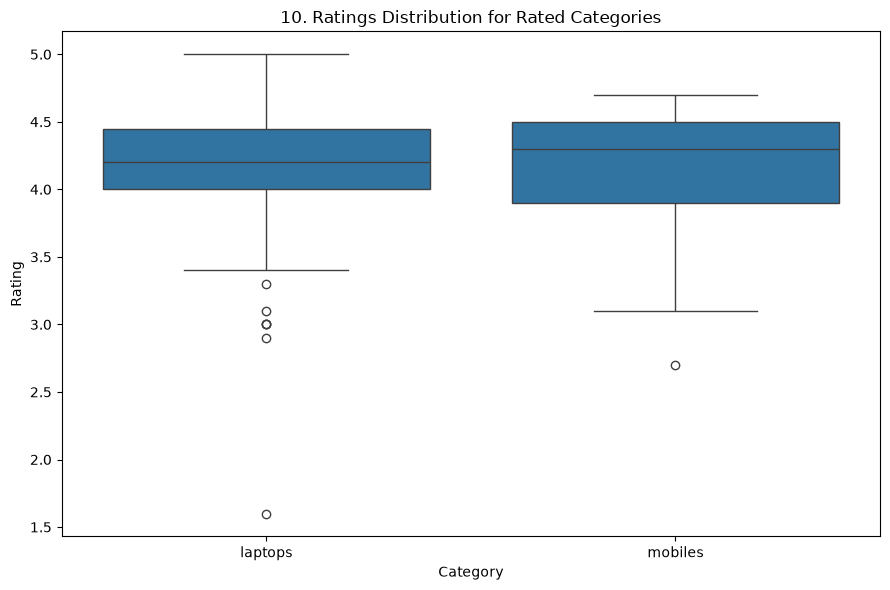

In [39]:

rating_df = raw[raw["Ratings"].notna()].copy()
plt.figure(figsize=(9,6))
sns.boxplot(data=rating_df, x="Category", y="Ratings")
plt.title("10. Ratings Distribution for Rated Categories")
plt.xlabel("Category")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

**How to read this chart:** as with the earlier box plots, the box shows
the middle 50% of ratings for that category, the line is the median rating,
and dots are unusually high or low outlier ratings.

### Step 36 — Chart: Overall Rating Distribution

A histogram showing how customer ratings are distributed across all rated
products, regardless of category.

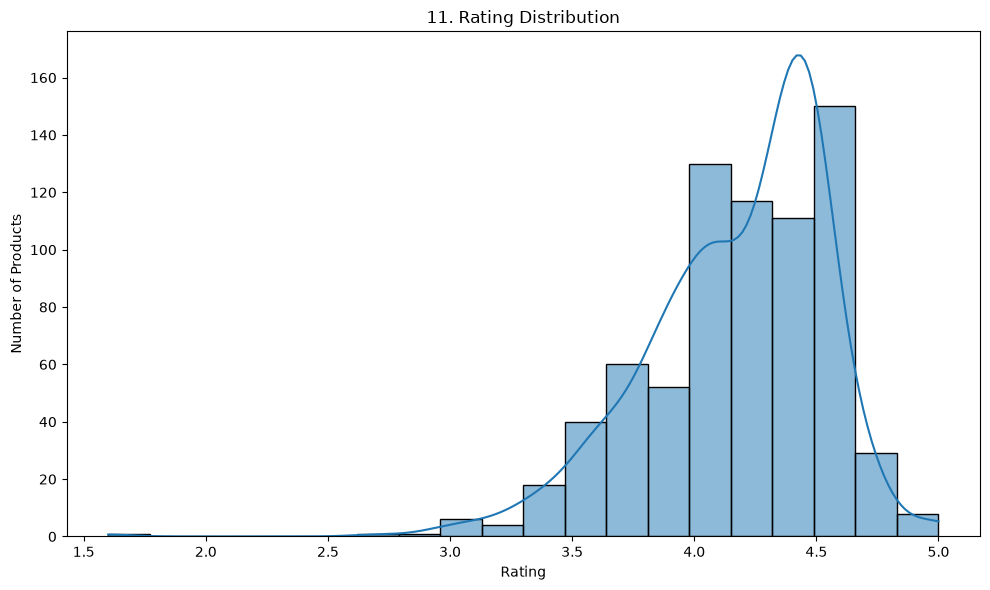

In [40]:

if "Ratings" in raw.columns:
    
    rating_data = raw.dropna(subset=["Ratings"])
    
    plt.figure(figsize=(10, 6))
    
    sns.histplot(
        rating_data["Ratings"],
        bins=20,
        kde=True
    )
    
    plt.title("11. Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Number of Products")
    
    plt.tight_layout()
    plt.show()

**How to read this chart:** most online marketplaces show ratings
clustering toward the higher end (3.5–4.5 out of 5), since very low-rated
products tend to get removed or rarely purchased. A tall peak shows the
most common rating range.

### Step 37 — Chart: Price vs. Rating

This scatter plot checks whether there's any visible relationship between
how much a product costs and how it's rated by customers, with each
category shown in a different colour.

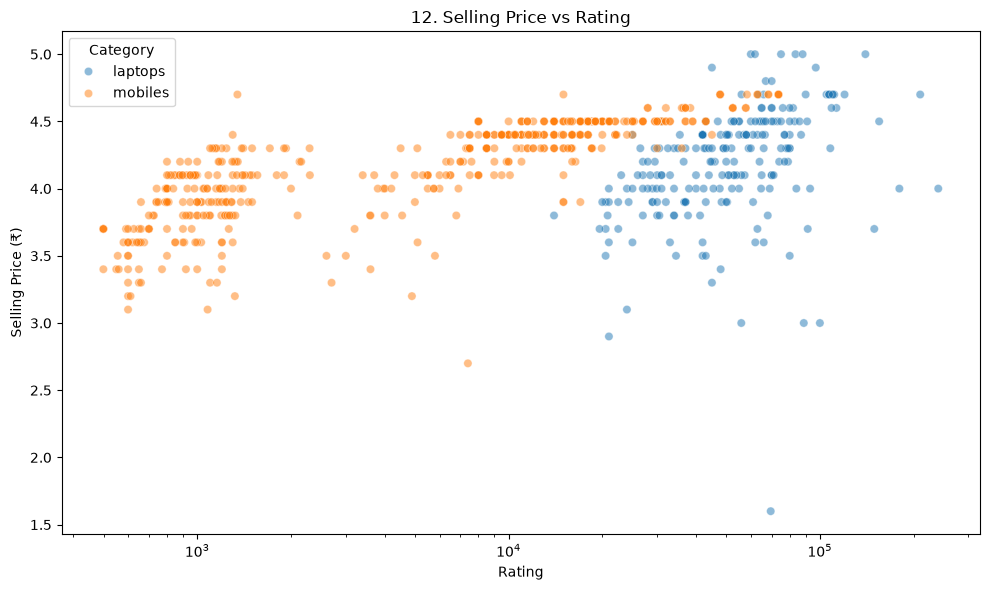

In [41]:

if "Ratings" in raw.columns:
    
    rating_data = raw.dropna(
        subset=["Ratings", "Price"]
    )
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=rating_data,
        y="Ratings",
        x="Price",
        hue="Category",
        alpha=0.5
    )
    plt.xscale("log")
    plt.title("12. Selling Price vs Rating")
    plt.xlabel("Rating")
    plt.ylabel("Selling Price (₹)")
    
    plt.tight_layout()
    plt.show()

**How to read this chart:** if expensive products were consistently
better rated, we'd see dots drift upward as we move right along the price
axis. If the dots look like a random scattered cloud with no clear pattern,
it means **price alone doesn't predict customer satisfaction** in this
dataset.

### Step 38 — Correlation Matrix

A correlation matrix measures how strongly pairs of numeric columns move
together. Values range from **-1 to +1**:

- **Close to +1** — as one value goes up, the other tends to go up too.
- **Close to -1** — as one value goes up, the other tends to go down.
- **Close to 0** — little to no relationship between the two.

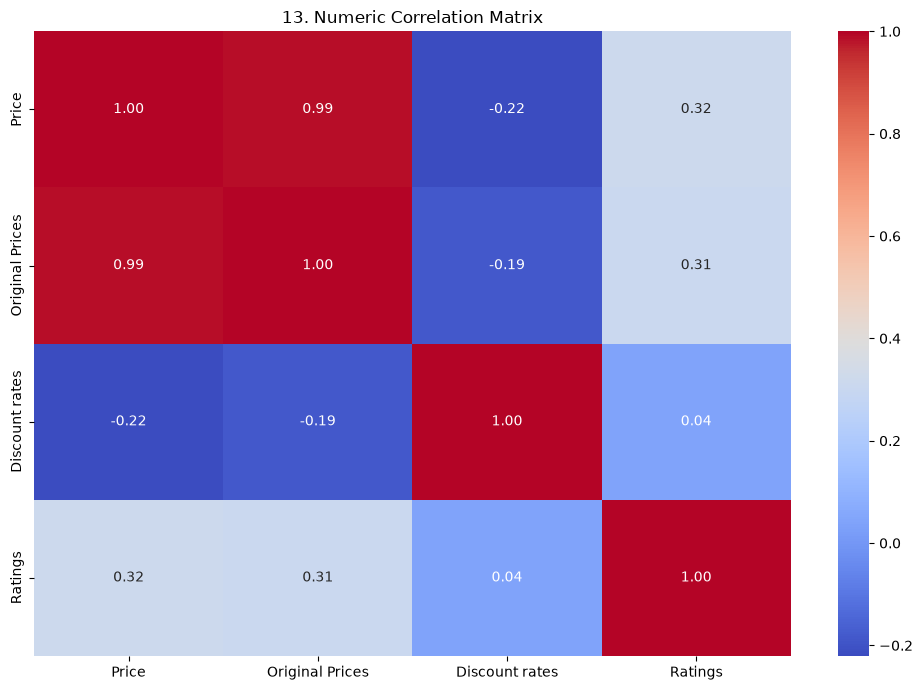

In [42]:

numeric_columns = raw.select_dtypes(
    include=np.number
)

correlation = numeric_columns.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("13. Numeric Correlation Matrix")

plt.tight_layout()
plt.show()

**How to read this heatmap:** warmer colours (typically red) indicate a
strong positive relationship, cooler colours (blue) indicate a strong
negative relationship, and pale/white cells indicate little relationship.
The number in each cell is the exact correlation value. For example, we'd
expect **Price** and **Original Prices** to be very strongly correlated,
since one is calculated from the other.

### Step 39 — Correlation Within Each Category

Overall correlation can hide different patterns that exist *within* a
specific category. Here we repeat the correlation calculation separately
for each category (limited to categories with enough rating data to make
the numbers meaningful).

In [43]:
 
corr_by_category = {}
for cat, g in raw.groupby("Category"):
    # sub = g[["Price","Original Prices","Discount","Savings","Ratings"]].corr(numeric_only=True)
    sub = g[["Price", "Original Prices", "Discount rates", "Ratings", ]].corr(numeric_only=True)  # type: ignore
    corr_by_category[cat] = sub

for cat, c in corr_by_category.items():
    if "Ratings" in c.columns and c["Ratings"].notna().sum() > 1:
        print(f"\n{cat}")
        display(c.round(3))


laptops


,Price,Original Prices,Discount rates,Ratings
Price,1.000,0.971,-0.263,0.311
Original Prices,0.971,1.000,-0.056,0.325
Discount rates,-0.263,-0.056,1.000,0.075
Ratings,0.311,0.325,0.075,1.000



mobiles


,Price,Original Prices,Discount rates,Ratings
Price,1.000,0.969,-0.101,0.650
Original Prices,0.969,1.000,0.056,0.642
Discount rates,-0.101,0.056,1.000,0.023
Ratings,0.650,0.642,0.023,1.000


**Why this matters:** the relationship between price and rating (for
example) might look flat overall, but could be positive in one category
(e.g. laptops, where paying more tends to mean better quality) and negative
in another — this breakdown lets us spot those category-specific
differences.

### Step 40 — Price Segmentation

To make prices easier to compare, we group every product into one of eight
**price bands**, from "₹500 or less" up to "more than ₹1,00,000." This table
shows how many products from each category fall into each band.

In [44]:

bins = [-np.inf,
   500, 1000, 5000, 10000, 25000, 50000, 100000,
    np.inf
]

labels = [
    "<=₹500", "₹501–₹1,000", "₹1,001–₹5,000", "₹5,001–₹10,000",
    "₹10,001–₹25,000", "₹25,001–₹50,000", "₹50,001–₹1,00,000", ">₹1,00,000"
]

raw["Price_Band"] = pd.cut(
    raw["Price"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# price_band_summary = (
#     raw["Price_Band"]
#     .value_counts()
#     .sort_index()
# )
price_band_summary = (
    raw.groupby(["Category","Price_Band"], observed=True)
    .size()
    .reset_index(name="Products")
)

display(price_band_summary)

,Category,Price_Band,Products
0,baby,<=₹500,408
1,baby,"₹501–₹1,000",148
2,baby,"₹1,001–₹5,000",75
3,books,<=₹500,523
4,books,"₹501–₹1,000",88
5,books,"₹1,001–₹5,000",25
6,food,<=₹500,459
7,food,"₹501–₹1,000",124
8,food,"₹1,001–₹5,000",34
9,food,"₹5,001–₹10,000",1


**How to read this table:** each row is a specific category + price-band
combination, with the `Products` column showing how many items from that
category fall into that price range. It's a more detailed, itemised version
of the average/median price charts shown earlier.

### Step 41 — Chart: Price-Band Distribution (by Category)

This bar chart visualizes the table from Step 40, showing how the price
bands are distributed within each category.

<Figure size 1000x600 with 0 Axes>

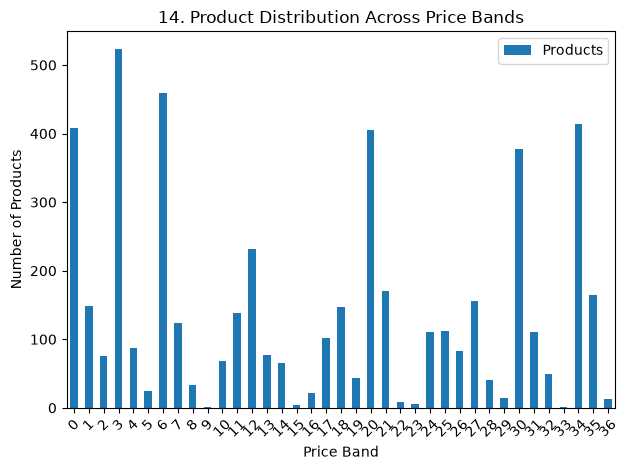

In [45]:

plt.figure(figsize=(10, 6))

price_band_summary.plot(kind="bar")

plt.title("14. Product Distribution Across Price Bands")
plt.xlabel("Price Band")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**How to read this chart:** each group of bars represents a category,
and the height of each bar within that group shows how many products in
that category fall into a specific price band. This makes it easy to see,
for example, whether a category is dominated by budget items or spread
across a wide range of prices.

### Step 42 — Chart: Overall Price-Band Composition

This chart shows the same price bands, but now combined across **all**
categories, giving an overall picture of how the whole catalog is priced.

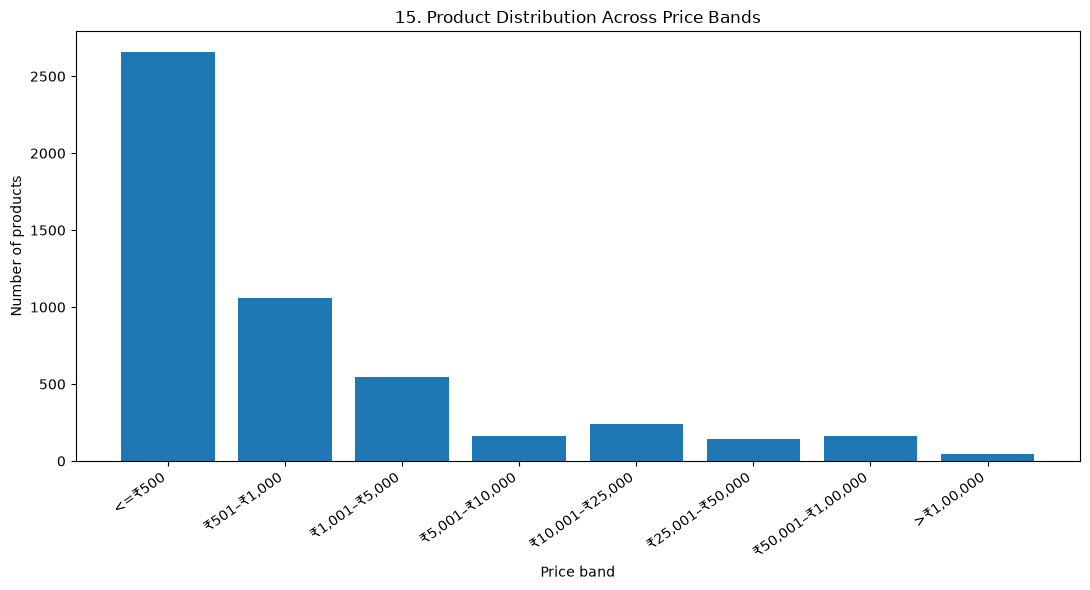

In [46]:

band_total = raw["Price_Band"].value_counts().reindex(labels).fillna(0)

plt.figure(figsize=(11,6))
plt.bar(band_total.index, band_total.values.tolist())
plt.title("15. Product Distribution Across Price Bands")
plt.xlabel("Price band")
plt.ylabel("Number of products")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**What to look for:** the tallest bar shows the price range where most
products in the entire catalog fall — this is useful for understanding the
platform's overall pricing strategy at a glance.

### Step 43 — Brand Analysis: How Many Products per Brand?

This table lists every brand found in the dataset, along with how many
products each brand has listed, sorted from most to least.

In [47]:

if "Brand" in raw.columns:
    
    brand_counts = (
        raw["Brand"]
        .value_counts()
        # .head(15)
    )
    
    display(brand_counts)

Brand
Sparx          37
Puma           35
FastColors     33
Tripr          33
Jockey         32
               ..
Lady Stark      1
Only            1
Fab Star        1
DMP FASHION     1
Greenwich       1
Name: count, Length: 534, dtype: int64

### Step 44 — Chart: Top 15 Brands by Product Count

A horizontal bar chart highlighting the 15 brands with the largest presence
(most listed products) in the dataset.

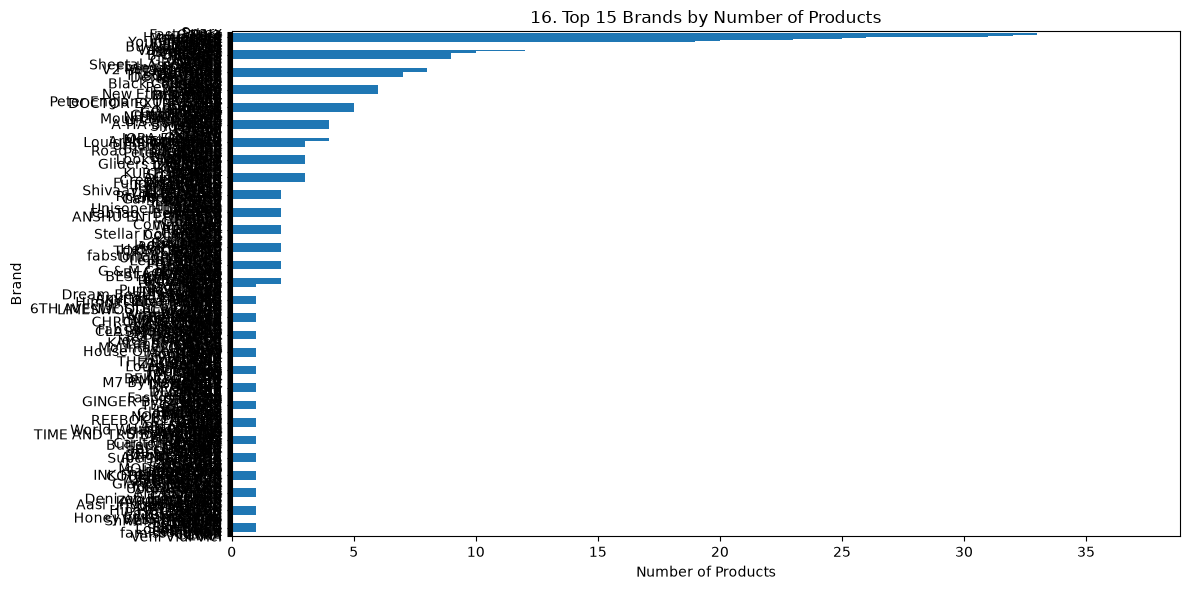

In [48]:

if "Brand" in raw.columns:
    
    plt.figure(figsize=(12, 6))
    
    brand_counts.sort_values().plot(
        kind="barh"
    )
    
    plt.title("16. Top 15 Brands by Number of Products")
    plt.xlabel("Number of Products")
    plt.ylabel("Brand")
    
    plt.tight_layout()
    plt.show()

**How to read this chart:** longer bars mean that brand has more
products listed across the catalog. A brand with a large product count has
a bigger "footprint" on the platform, though this doesn't necessarily mean
it sells the most units.

### Step 45 — Chart: Top Brands by Average Discount

This chart looks at things differently — instead of product count, it ranks
brands (with at least 10 products, to keep the comparison meaningful) by
their **average discount percentage**.

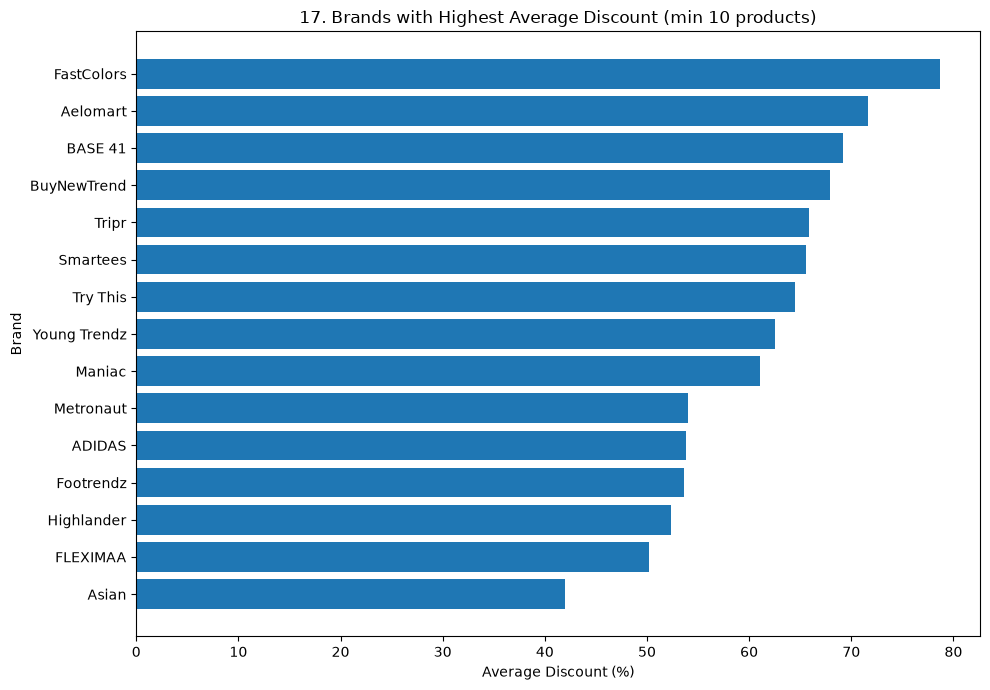

['Product Name', 'Price', 'Original Prices', 'Discount rates', 'Category', 'Ratings', 'Brand', 'Price_Band']


In [49]:

top_discount_brands = (
    raw.groupby("Brand")["Discount rates"]
       .agg(["mean", "count"])
       .query("count >= 10")
       .sort_values("mean", ascending=True)
       .tail(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_discount_brands.index,
    top_discount_brands["mean"]
)

plt.title("17. Brands with Highest Average Discount (min 10 products)")
plt.xlabel("Average Discount (%)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()
print(raw.columns.tolist())

**How to read this chart:** the longer the bar, the bigger the typical
discount that brand offers across its product range. Brands at the top of
this chart consistently price their products with steep markdowns compared
to their original price.

### Step 46 — Category-wise Brand Totals

Finally, we build two more detailed summary tables: one showing total
sales-relevant figures (product count, number of distinct brands, total
price, total discount amount, and average discount) **per category**, and
one broken down further to the **category + brand** level.

In [50]:
category_totals = (
    raw.groupby("Category")
       .agg(
           Product_Count=("Product Name", "count"),
           Brand_Count=("Brand", "nunique"),
           Total_Price=("Price", "sum"),
           Total_Original_Price=("Original Prices", "sum"),
           Average_Discount_Rate=("Discount rates", "mean")
       )
       .reset_index()
)

category_totals

,Category,Product_Count,Brand_Count,Total_Price,Total_Original_Price,Average_Discount_Rate
0,baby,631,0,341840.0,465692.0,19.730586
1,books,636,0,236357.0,313334.0,23.056604
2,food,619,0,261679.0,336817.0,16.625202
3,furn,586,0,2325838.0,3767316.0,40.687713
4,laptops,314,0,21557887.0,24836514.0,13.210191
5,mens_westernwear,584,167,254806.0,664135.0,56.008562
6,mobiles,521,0,5720329.0,6616693.0,12.239923
7,women_footwear,539,182,341587.0,576477.0,36.658627
8,women_westernwear,591,212,275100.0,768859.0,62.045685


In [51]:
raw["Discount_Amount"] = raw["Original Prices"] - raw["Price"]

category_totals = (
    raw.groupby("Category")
       .agg(
           Product_Count=("Product Name", "count"),
           Brand_Count=("Brand", "nunique"),
           Total_Price=("Price", "sum"),
           Total_Original_Price=("Original Prices", "sum"),
           Total_Discount_Amount=("Discount_Amount", "sum"),
           Average_Discount_Rate=("Discount rates", "mean")
       )
       .reset_index()
       .round(2)
)

category_totals

,Category,Product_Count,Brand_Count,Total_Price,Total_Original_Price,Total_Discount_Amount,Average_Discount_Rate
0,baby,631,0,341840.0,465692.0,123852.0,19.73
1,books,636,0,236357.0,313334.0,76977.0,23.06
2,food,619,0,261679.0,336817.0,75138.0,16.63
3,furn,586,0,2325838.0,3767316.0,1441478.0,40.69
4,laptops,314,0,21557887.0,24836514.0,3278627.0,13.21
5,mens_westernwear,584,167,254806.0,664135.0,409329.0,56.01
6,mobiles,521,0,5720329.0,6616693.0,896364.0,12.24
7,women_footwear,539,182,341587.0,576477.0,234890.0,36.66
8,women_westernwear,591,212,275100.0,768859.0,493759.0,62.05


In [52]:

brand_summary = (
    raw.groupby(["Category", "Brand"])
       .agg(
           Product_Count=("Product Name", "count"),
           Total_Price=("Price", "sum"),
           Total_Original_Price=("Original Prices", "sum"),
           Total_Discount_Amount=("Discount rates", "sum"),
           Average_Discount_Rate=("Discount rates", "mean")
       )
       .reset_index()
       .round(2)
)

brand_summary

,Category,Brand,Product_Count,Total_Price,Total_Original_Price,Total_Discount_Amount,Average_Discount_Rate
0,mens_westernwear,3mads,1,97.0,799.0,87,87.0
1,mens_westernwear,A-Okay,1,498.0,1875.0,73,73.0
2,mens_westernwear,AD & AV,2,1218.0,3598.0,130,65.0
3,mens_westernwear,ADIDAS,23,5312.0,11757.0,1291,56.13
4,mens_westernwear,AMEXTRIAN,1,395.0,1999.0,80,80.0
...,...,...,...,...,...,...,...
556,women_westernwear,pdpm,6,1894.0,3664.0,266,44.33
557,women_westernwear,popwings,2,988.0,2598.0,122,61.0
558,women_westernwear,silkova,2,698.0,3998.0,165,82.5
559,women_westernwear,upperkutt,3,1125.0,4497.0,217,72.33


**How to read these tables:** the first table (`category_totals`) rolls
everything up to one row per category — useful for a high-level comparison.
The second (`brand_summary`) breaks the same figures down to one row per
brand *within* each category, which is useful for identifying, for example,
which specific brands are driving a category's overall discount level.

## Part 4 — Key Business Insights

To wrap up, we pull together the numbers calculated earlier into a short, plain-English list of headline findings, along with a few honest caveats about what this data can and can't tell us.

In [53]:
# 33. Automated business-insight tables
highest_avg_price = category_summary["Avg_Price"].idxmax()
highest_discount = category_summary["Avg_Discount"].idxmax()
lowest_discount = category_summary["Avg_Discount"].idxmin()
highest_median_price = category_summary["Median_Price"].idxmax()

print("KEY BUSINESS INSIGHTS")
print("="*70)
print(f"1. Highest average selling price category: {highest_avg_price} "
      f"(₹{category_summary.loc[highest_avg_price,'Avg_Price']:,.0f}).")
print(f"2. Highest median selling price category: {highest_median_price} "
      f"(₹{category_summary.loc[highest_median_price,'Median_Price']:,.0f}).")
print(f"3. Highest average listed discount: {highest_discount} "
      f"({category_summary.loc[highest_discount,'Avg_Discount']:.1f}%).")
print(f"4. Lowest average listed discount: {lowest_discount} "
      f"({category_summary.loc[lowest_discount,'Avg_Discount']:.1f}%).")

if "Ratings" in raw.columns:
    rated = raw.dropna(subset=["Ratings"])
    if not rated.empty:
        best_rated_cat = rated.groupby("Category")["Ratings"].mean().idxmax()
        print(f"5. Highest average rating among rated categories: {best_rated_cat} "
              f"({rated.groupby('Category')['Ratings'].mean().max():.2f}).")

print("\nInterpretation cautions:")
print("- A high listed discount does not prove high sales or profitability.")
print("- Product count is catalog coverage, not market share.")
print("- Ratings are available only for some categories and may be missing/non-random.")
print("- Duplicate removal is appropriate for repeated identical rows, but real marketplace listings may legitimately repeat products.")
print("- Outliers should be investigated, not automatically deleted.")

KEY BUSINESS INSIGHTS
1. Highest average selling price category: laptops (₹68,656).
2. Highest median selling price category: laptops (₹58,744).
3. Highest average listed discount: women_westernwear (62.0%).
4. Lowest average listed discount: mobiles (12.2%).
5. Highest average rating among rated categories: laptops (4.18).

Interpretation cautions:
- A high listed discount does not prove high sales or profitability.
- Product count is catalog coverage, not market share.
- Ratings are available only for some categories and may be missing/non-random.
- Duplicate removal is appropriate for repeated identical rows, but real marketplace listings may legitimately repeat products.
- Outliers should be investigated, not automatically deleted.


### Reading the Insights Above

The five numbered points summarise the single most notable category (or
brand) for each measure we've studied in this notebook — highest price,
highest discount, lowest discount, and best-rated category.

The **"Interpretation cautions"** at the end are just as important as the
headline numbers: they're a reminder that a discount percentage, a product
count, or a rating average is only ever one piece of the full business
picture, and shouldn't be treated as a complete measure of sales,
profitability, or product quality on its own.

---
### Summary

This notebook took nine separate, messy category export files, cleaned and
combined them into one trustworthy dataset, and then explored that dataset
from several angles — price, discount, ratings, brands, and price
segments — using both summary tables and charts. The result is a
data-backed, plain-English picture of how Flipkart's product catalog is
priced and discounted across categories, ready to support further business
discussion or reporting.